In [72]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, \
                            confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt  
import japanize_matplotlib

In [73]:
df = pd.read_csv("../data/raw/train.csv", encoding="shift-jis")


In [74]:
df.head()

,sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,...,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139
0,1,1,イチョウ,216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.41470,...,1.25104,1.24925,1.24145,1.23620,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219
1,2,1,イチョウ,210.752688,0.42049,0.42040,0.42049,0.42053,0.42038,0.42010,...,1.21929,1.21611,1.21565,1.21745,1.21680,1.21205,1.21074,1.21508,1.21901,1.21846
2,3,1,イチョウ,205.913979,0.41040,0.41045,0.41047,0.41028,0.41000,0.40989,...,1.17471,1.17147,1.16611,1.16633,1.16998,1.16955,1.16200,1.15341,1.15139,1.15403
3,4,1,イチョウ,201.075269,0.40080,0.40061,0.40031,0.40008,0.39993,0.39991,...,1.11271,1.11339,1.11115,1.10965,1.11017,1.11165,1.11426,1.11787,1.11849,1.11328
4,5,1,イチョウ,196.236559,0.38792,0.38814,0.38825,0.38817,0.38798,0.38778,...,1.05617,1.05596,1.05760,1.06014,1.06240,1.06566,1.06962,1.07056,1.06459,1.05612


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Columns: 1559 entries, sample number to 3999.82139
dtypes: float64(1556), int64(2), object(1)
memory usage: 15.7+ MB


In [76]:
# 波数カラムの抽出
wavenumber_cols = [c for c in df.columns if c not in ["sample number", "species number", "樹種", "含水率"]]
wavenumbers = np.array(wavenumber_cols, dtype=float)

print(f"波数カラム数: {len(wavenumber_cols)}")
print(f"波数範囲: {wavenumbers.min():.1f} ~ {wavenumbers.max():.1f} cm⁻¹")

波数カラム数: 1555
波数範囲: 3999.8 ~ 9993.8 cm⁻¹


### 全スペクトル（含水率で色分け）

In [77]:
# fig, ax = plt.subplots(figsize=(14, 5))
#
# mc = df["含水率"].values
# norm = plt.Normalize(mc.min(), mc.max())
# cmap = plt.cm.RdYlBu_r  # 低含水率=青, 高含水率=赤
#
# # 全1322スペクトルを重ねてプロット（透明度を下げて密度感を出す）
# for i in range(len(df)):
#     ax.plot(wavenumbers, df[wavenumber_cols].values[i], color=cmap(norm(mc[i])), alpha=0.15, linewidth=0.4)
#
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("含水率 (%)", fontsize=12)
#
# ax.set_xlabel("波数 (cm⁻¹)", fontsize=12)
# ax.set_ylabel("吸光度", fontsize=12)
# ax.set_title("NIR スペクトル（全サンプル・含水率グラデーション）", fontsize=14)
# ax.invert_xaxis()  # NIR慣習：高波数→低波数
# plt.tight_layout()
# plt.show()

### 含水率ビン別の平均スペクトル

In [78]:
# # 含水率を5段階にビン分け
# bins = [0, 20, 50, 100, 150, 999]
# labels = ["0–20%", "20–50%", "50–100%", "100–150%", "150%+"]
# df["含水率_bin"] = pd.cut(df["含水率"], bins=bins, labels=labels)
#
# print(df["含水率_bin"].value_counts().sort_index())

In [79]:
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
#
# palette = ["#2166ac", "#74add1", "#fdae61", "#f46d43", "#a50026"]
#
# # --- 左: ビン別の平均スペクトル + 標準偏差シェード ---
# ax = axes[0]
# for i, (label, color) in enumerate(zip(labels, palette)):
#     subset = df[df["含水率_bin"] == label][wavenumber_cols].values
#     if len(subset) == 0:
#         continue
#     mean = subset.mean(axis=0)
#     std  = subset.std(axis=0)
#     ax.plot(wavenumbers, mean, color=color, linewidth=1.5, label=f"{label} (n={len(subset)})")
#     ax.fill_between(wavenumbers, mean - std, mean + std, color=color, alpha=0.15)
#
# ax.invert_xaxis()
# ax.set_xlabel("波数 (cm⁻¹)", fontsize=12)
# ax.set_ylabel("吸光度（平均 ± std）", fontsize=12)
# ax.set_title("含水率ビン別 平均スペクトル", fontsize=13)
# ax.legend(fontsize=9)
#
# # --- 右: 差分スペクトル（各ビン平均 − 最乾燥ビン平均）---
# ax2 = axes[1]
# ref_label = "0–20%"
# ref_mean = df[df["含水率_bin"] == ref_label][wavenumber_cols].values.mean(axis=0)
#
# for label, color in zip(labels[1:], palette[1:]):
#     subset = df[df["含水率_bin"] == label][wavenumber_cols].values
#     if len(subset) == 0:
#         continue
#     diff = subset.mean(axis=0) - ref_mean
#     ax2.plot(wavenumbers, diff, color=color, linewidth=1.5, label=label)
#
# ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
# ax2.invert_xaxis()
# ax2.set_xlabel("波数 (cm⁻¹)", fontsize=12)
# ax2.set_ylabel("吸光度差（対 0–20%）", fontsize=12)
# ax2.set_title("差分スペクトル（含水率増加による変化）", fontsize=13)
# ax2.legend(fontsize=9)
#
# plt.tight_layout()
# plt.show()

### 樹種 × 含水率ビン別の平均スペクトル

In [80]:
# species_list = df["樹種"].unique()
# n_species = len(species_list)
# ncols = 3
# nrows = (n_species + ncols - 1) // ncols
#
# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5), sharey=False)
# axes = axes.flatten()
#
# for ax, species in zip(axes, species_list):
#     sub = df[df["樹種"] == species]
#     for label, color in zip(labels, palette):
#         grp = sub[sub["含水率_bin"] == label][wavenumber_cols].values
#         if len(grp) == 0:
#             continue
#         ax.plot(wavenumbers, grp.mean(axis=0), color=color, linewidth=1.2, label=label)
#     ax.invert_xaxis()
#     ax.set_title(species, fontsize=11)
#     ax.set_xlabel("波数 (cm⁻¹)", fontsize=8)
#     ax.set_ylabel("吸光度", fontsize=8)
#     ax.tick_params(labelsize=7)
#
# # 余ったaxesを非表示
# for ax in axes[n_species:]:
#     ax.set_visible(False)
#
# # 共通凡例
# handles = [plt.Line2D([0], [0], color=c, linewidth=1.5, label=l) for l, c in zip(labels, palette)]
# fig.legend(handles=handles, title="含水率", loc="lower right", fontsize=9, title_fontsize=10)
#
# fig.suptitle("樹種別・含水率ビン別 平均スペクトル", fontsize=14, y=1.01)
# plt.tight_layout()
# plt.show()

## 全樹種 EDA

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


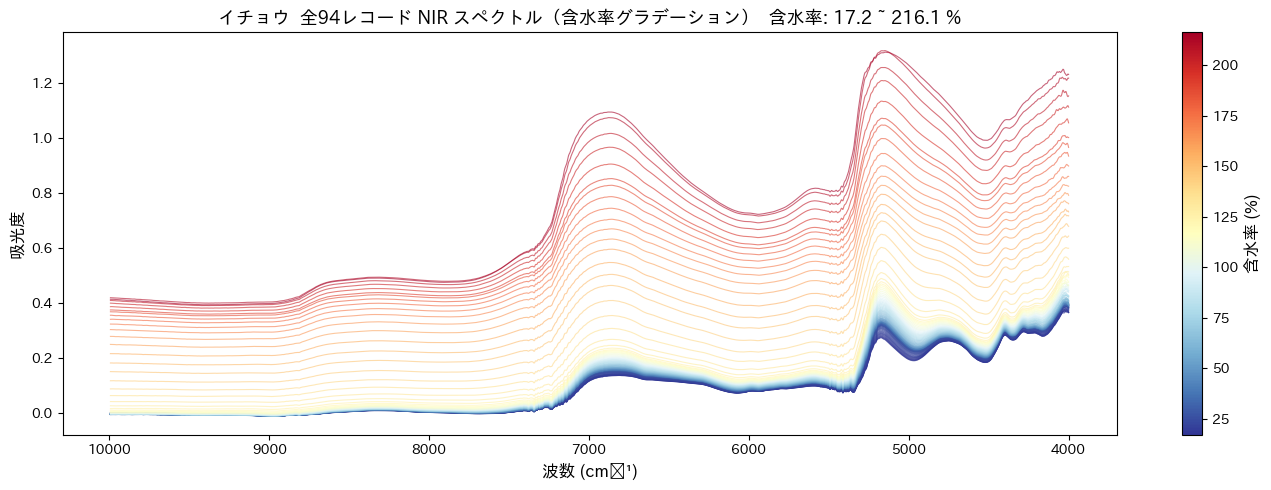

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


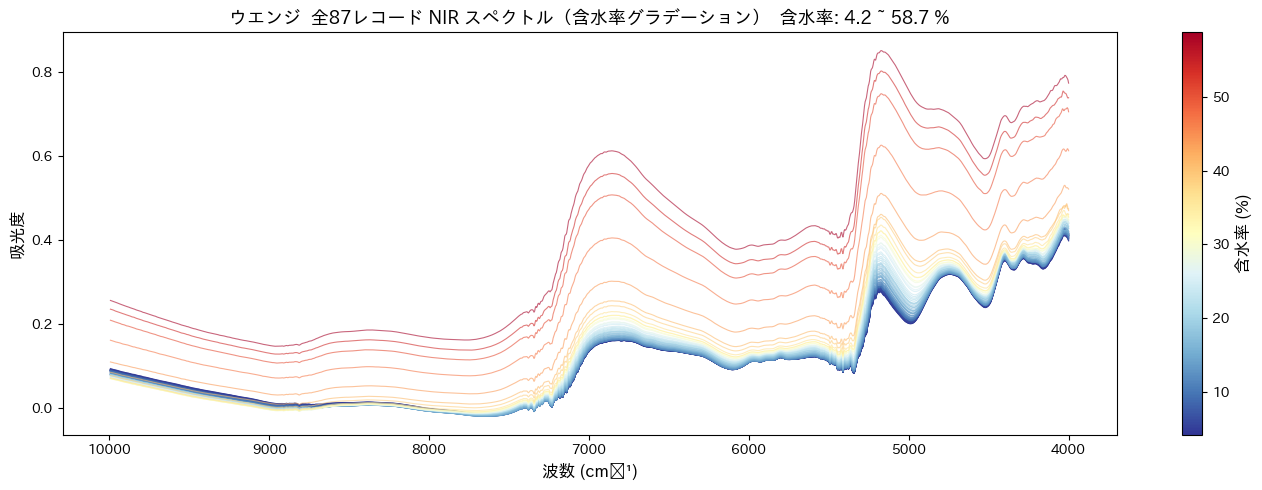

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


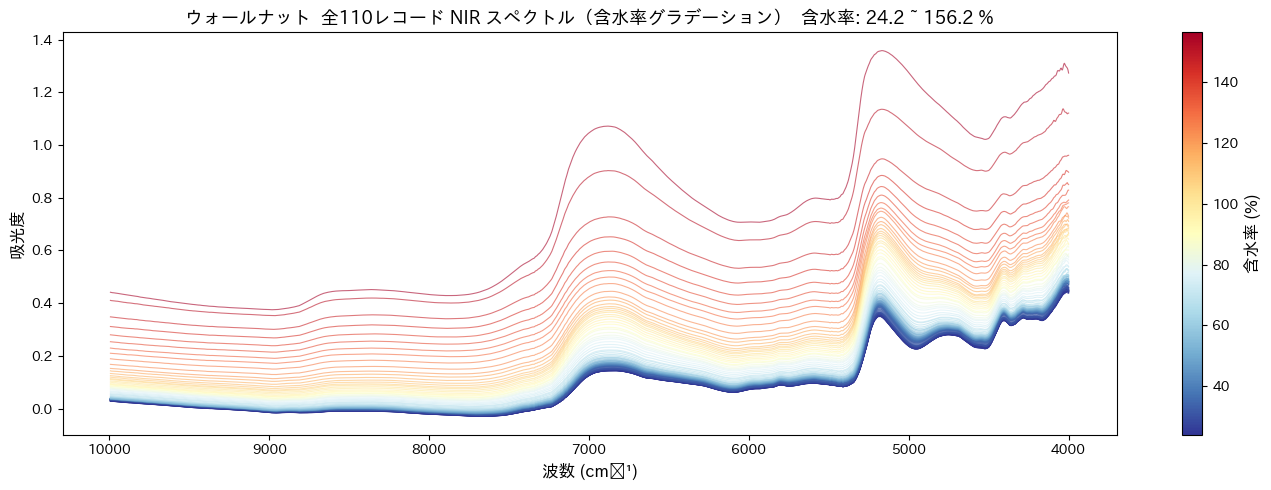

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


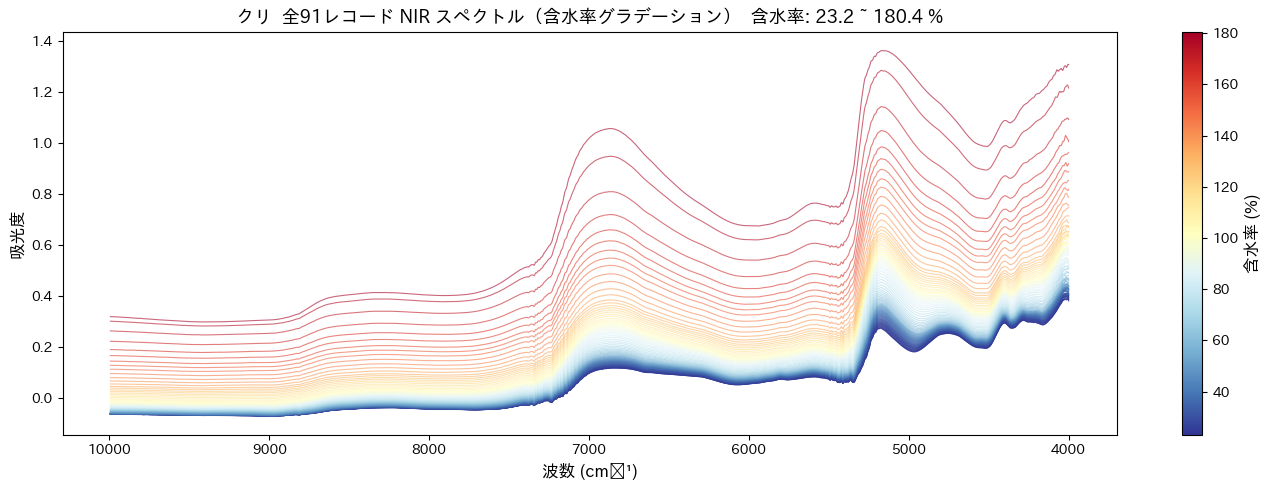

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


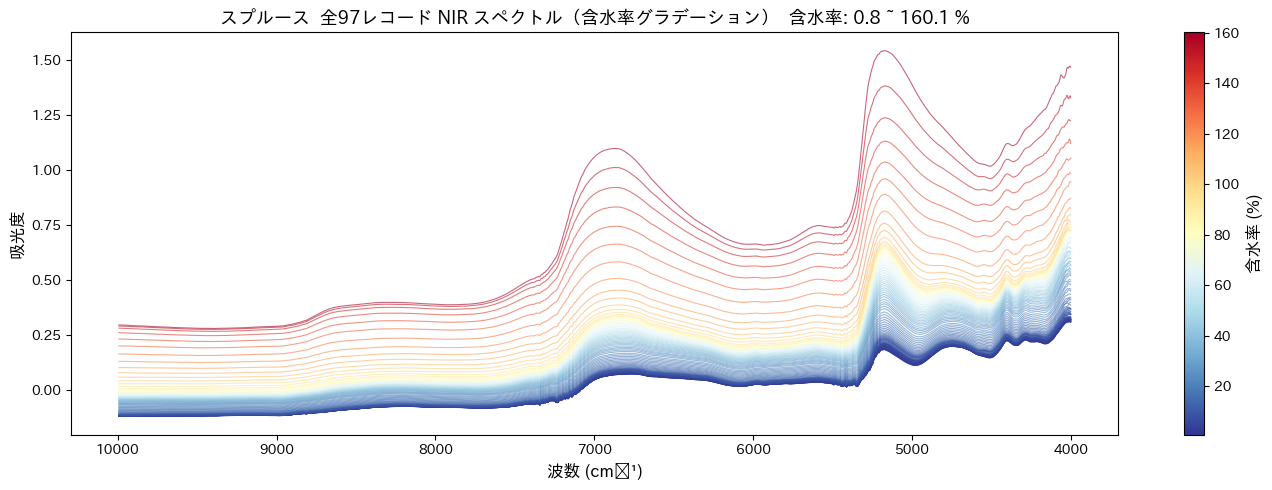

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


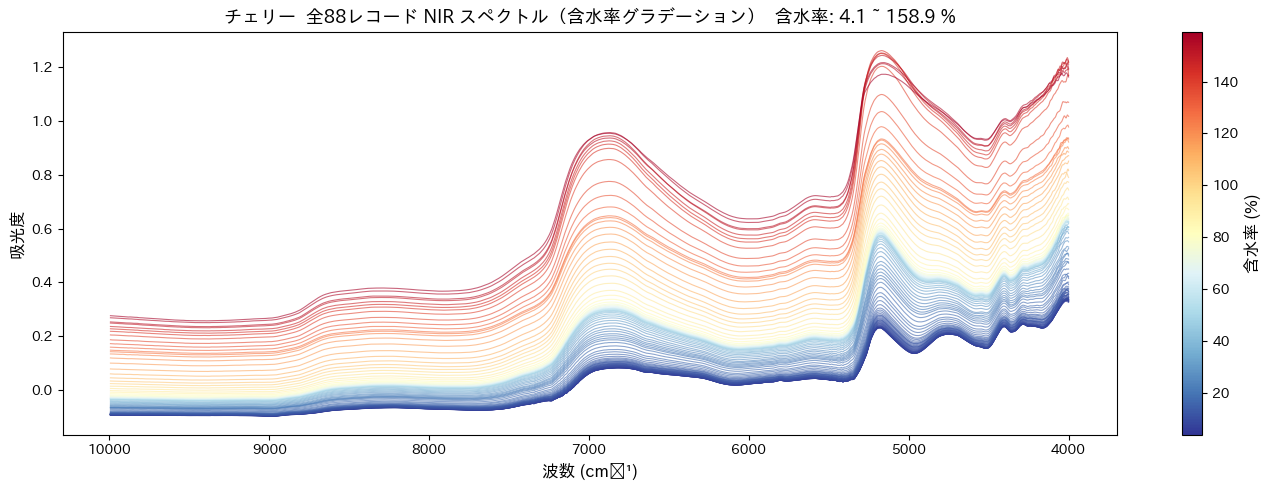

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


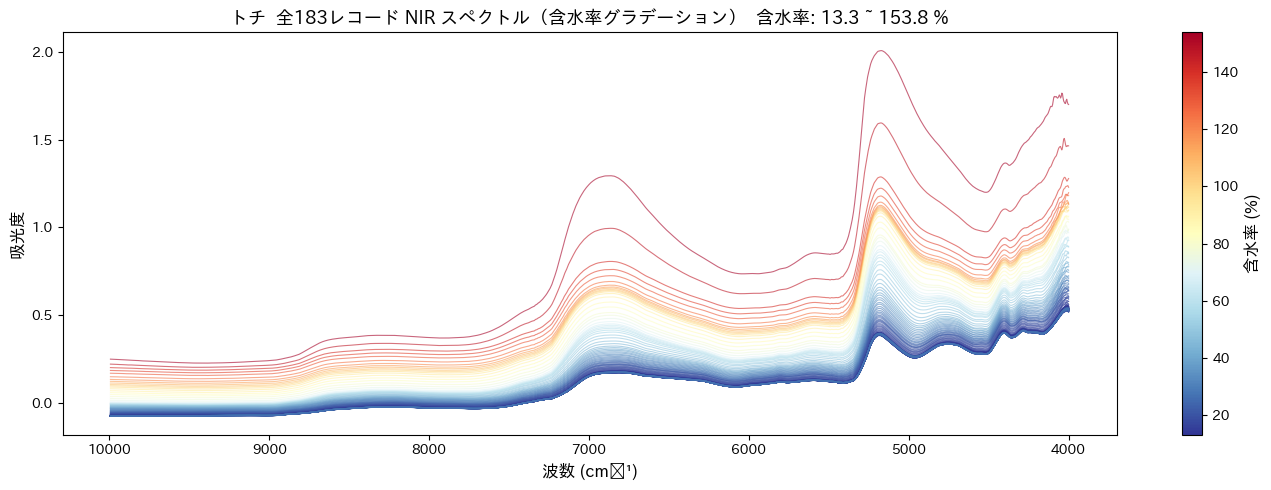

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


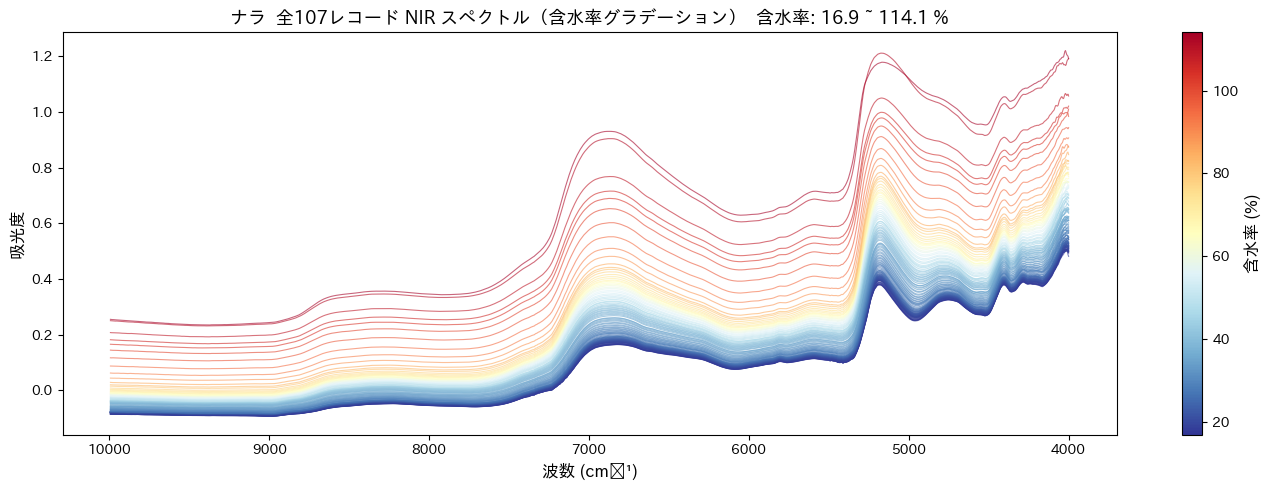

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


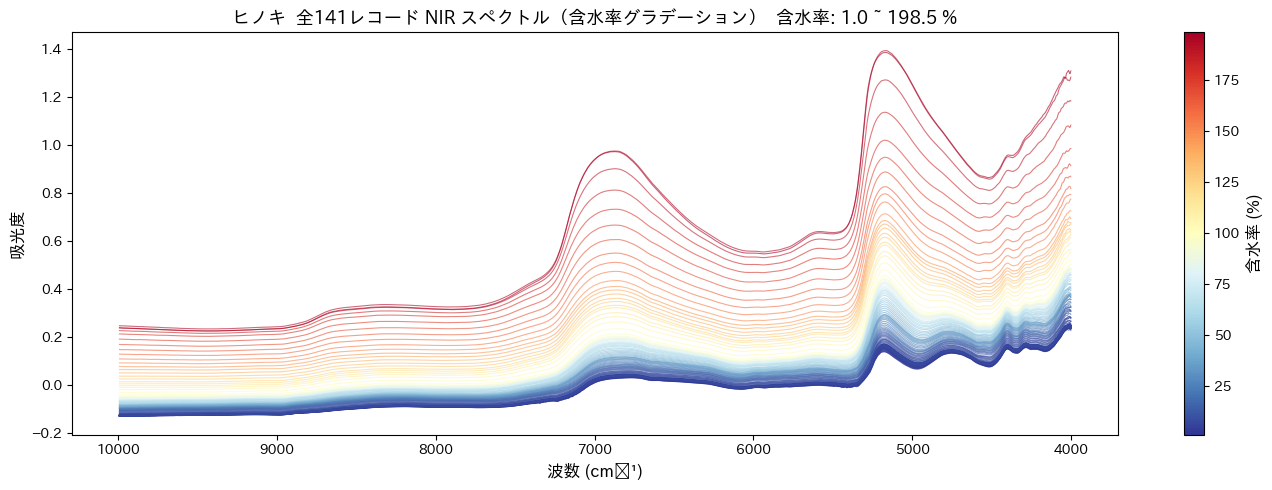

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


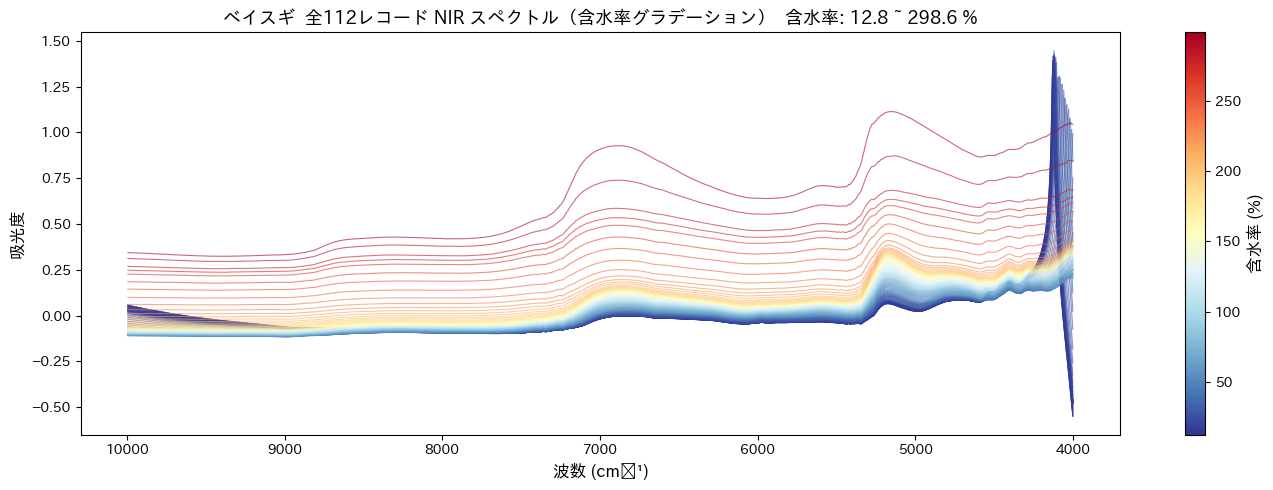

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


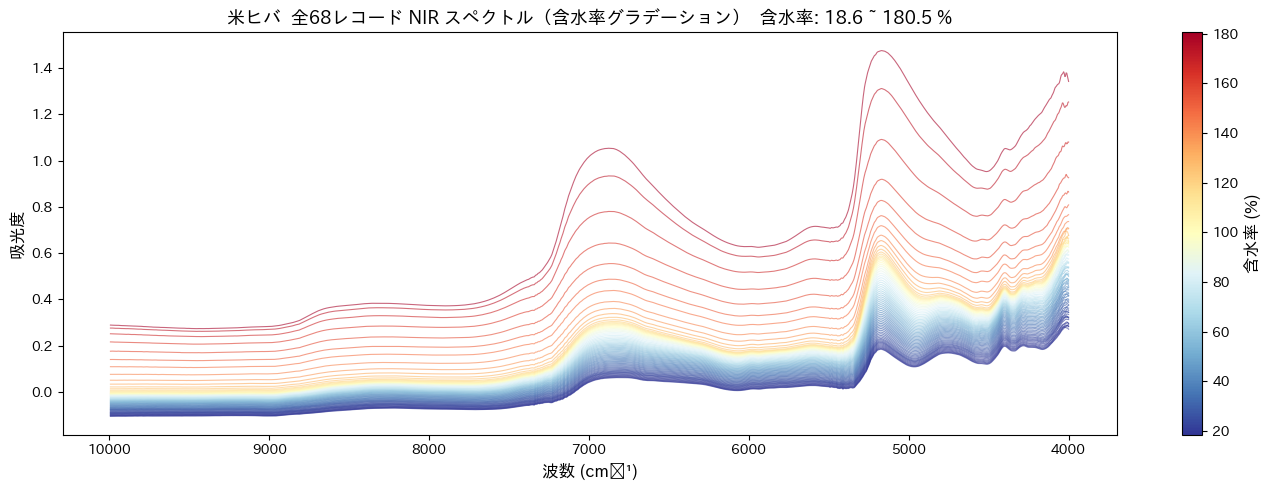

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


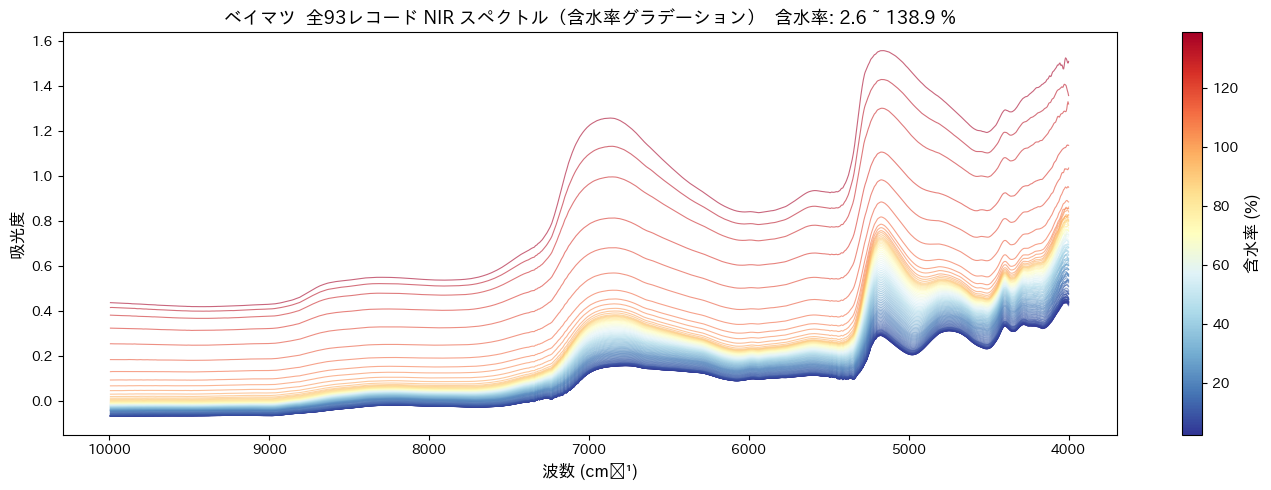

/var/folders/z_/txvnb6c9181dlk4wqs496xd00000gp/T/ipykernel_5549/3316984318.py:24: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


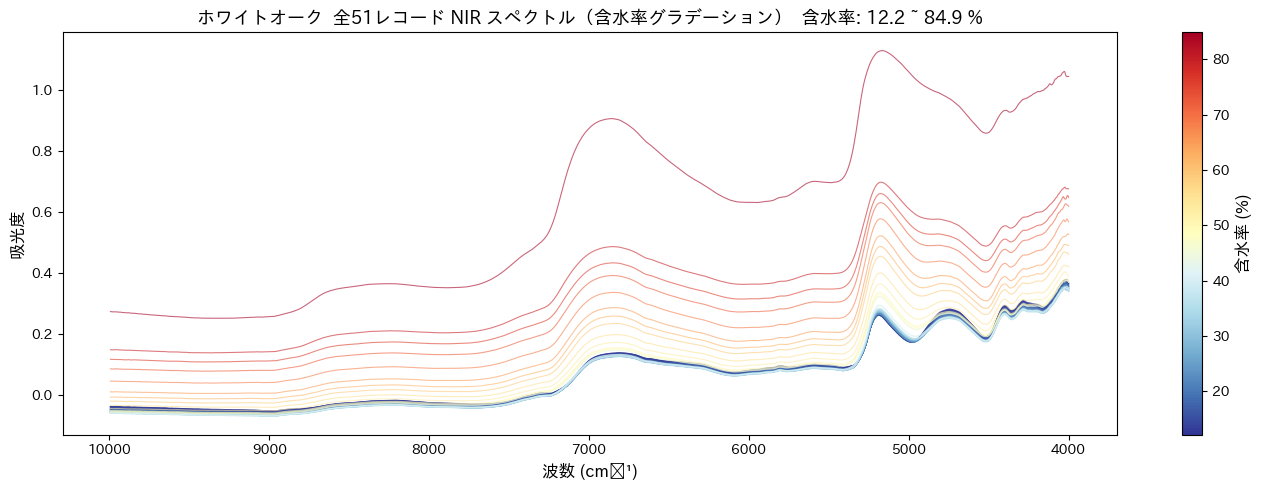

In [81]:
other_species = [s for s in df["樹種"].unique()]

for species in other_species:
    df_sp = df[df["樹種"] == species].sort_values("含水率").reset_index(drop=True)
    mc_sp = df_sp["含水率"].values
    norm = plt.Normalize(mc_sp.min(), mc_sp.max())
    cmap = plt.cm.RdYlBu_r

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, row in df_sp.iterrows():
        ax.plot(wavenumbers, row[wavenumber_cols].values,
                color=cmap(norm(row["含水率"])), alpha=0.6, linewidth=0.8)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("含水率 (%)", fontsize=12)

    ax.invert_xaxis()
    ax.set_xlabel("波数 (cm⁻¹)", fontsize=12)
    ax.set_ylabel("吸光度", fontsize=12)
    ax.set_title(f"{species}  全{len(df_sp)}レコード NIR スペクトル（含水率グラデーション）  "
                 f"含水率: {mc_sp.min():.1f} ~ {mc_sp.max():.1f} %", fontsize=13)
    plt.tight_layout()
    plt.show()